# 02 — Albert Street Duplicate Investigation

This notebook investigates duplicate-looking raw bicycle records for **Albert Street counter 9077**.

## Main questions

1. How many duplicate rows are present?
2. How many unique duplicate groups are there?
3. Do duplicate groups occur within the same source CSV/ZIP?
4. Do identical observations appear across different CSV or ZIP files?
5. How often is each duplicated observation repeated?
6. What percentage of Albert's raw records is affected?
7. How much would removing exact duplicates change the daily counts and before/after averages?

## Important note

This notebook does **not** overwrite the original files. Any cleaned dataset is created as a separate DataFrame and exported separately.


## 1. Import libraries and configure paths


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


from pathlib import Path
import os
import yaml

def find_project_root(start=None):
    """Find the repository root by looking for .git or config.yaml."""
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() or (candidate / "config.yaml").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()

config_path = PROJECT_ROOT / "config.yaml"
config = {}
if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f) or {}

paths_cfg = config.get("paths", {})

RAW_ROOT = PROJECT_ROOT / paths_cfg.get("raw_dir", "data/raw")
PROCESSED_ROOT = PROJECT_ROOT / paths_cfg.get("processed_dir", "data/processed")

# Optional override for local machines:
# Windows PowerShell example:
#   $env:CYCLING_DATA_DIR="D:\\path\\to\\CYCLING_DATA"
CYCLING_DATA_DIR = Path(
    os.environ.get(
        "CYCLING_DATA_DIR",
        RAW_ROOT / "cycling_data"
    )
).expanduser().resolve()

CYCLING_PROCESSED_DIR = PROCESSED_ROOT / "cycling_counters"
CYCLING_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cycling raw data:", CYCLING_DATA_DIR)
print("Cycling processed data:", CYCLING_PROCESSED_DIR)

EXTRACTION_DIR = CYCLING_PROCESSED_DIR / "extraction"
OUTPUT_DIR = CYCLING_PROCESSED_DIR / "duplicate_investigation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILE = EXTRACTION_DIR / "cycling_required_counters_raw.csv"
DUPLICATE_FILE = EXTRACTION_DIR / "duplicate_records.csv"
DAILY_FILE = EXTRACTION_DIR / "daily_bicycle_volume.csv"

print("Output folder:", OUTPUT_DIR)


Project root: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning
Cycling raw data: C:\Users\f_tir\OneDrive\Documents\UNI_2026\CAPSTONE PROJECT\A- TEAM A\CYCLING_DATA
Cycling processed data: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters
Output folder: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\duplicate_investigation


## 2. Load Albert raw records and duplicate records


In [2]:
SITE_ID = 9077
STREET_NAME = "Albert Street"
INTERVENTION_DATE = pd.Timestamp("2020-06-04")

raw = pd.read_csv(
    RAW_FILE,
    low_memory=False
)

duplicates = pd.read_csv(
    DUPLICATE_FILE,
    low_memory=False
)

albert_raw = raw.loc[
    pd.to_numeric(raw["SITE_ID"], errors="coerce") == SITE_ID
].copy()

albert_dup = duplicates.loc[
    pd.to_numeric(duplicates["SITE_ID"], errors="coerce") == SITE_ID
].copy()

print("Albert raw rows:", len(albert_raw))
print("Albert duplicate rows:", len(albert_dup))
print("Duplicate-row percentage:",
      round((len(albert_dup) / len(albert_raw)) * 100, 4)
      if len(albert_raw) else 0,
      "%")

albert_dup.head()


Albert raw rows: 902230
Albert duplicate rows: 1996
Duplicate-row percentage: 0.2212 %


,DATA_TYPE,TIS_DATA_REQUEST,SITE_XN_ROUTE,LOC_LEG,DATE,TIME,CLASS,LANE,SPEED,WHEELBASE,...,AXLE,AXLE_GROUPING,RHO,VEHICLE,DIRECTION,SITE_ID,SOURCE_ZIP,SOURCE_CSV,DATE_PARSED,STREET
9877,IND,208,9077,40292,02/01/2019,06:51:52,15,2,25.1,1.0,...,2,1,1.00,CYCLE,W,9077,2019-01-06_IND.zip,IND_D208_X9077.csv,2019-01-02,Albert Street
9878,IND,208,9077,40292,02/01/2019,06:51:52,15,2,25.1,1.0,...,2,1,1.00,CYCLE,W,9077,2019-01-06_IND.zip,IND_D208_X9077.csv,2019-01-02,Albert Street
9879,IND,208,9077,40292,02/01/2019,06:51:52,15,2,25.1,1.0,...,2,1,1.00,CYCLE,W,9077,2019-01-06_IND.zip,IND_D208_X9077.csv,2019-01-02,Albert Street
9880,IND,208,9077,40292,07/01/2019,06:54:32,15,2,16.2,1.0,...,2,1,1.08,CYCLE,W,9077,2019-01-13_IND.zip,IND_D208_X9077.csv,2019-01-07,Albert Street
9881,IND,208,9077,40292,07/01/2019,06:54:32,15,2,16.2,1.0,...,2,1,1.08,CYCLE,W,9077,2019-01-13_IND.zip,IND_D208_X9077.csv,2019-01-07,Albert Street


## 3. Check the available columns


In [3]:
print("Raw columns:")
print(albert_raw.columns.tolist())

print("\nDuplicate columns:")
print(albert_dup.columns.tolist())


Raw columns:
['DATA_TYPE', 'TIS_DATA_REQUEST', 'SITE_XN_ROUTE', 'LOC_LEG', 'DATE', 'TIME', 'CLASS', 'LANE', 'SPEED', 'WHEELBASE', 'HEADWAY', 'GAP', 'AXLE', 'AXLE_GROUPING', 'RHO', 'VEHICLE', 'DIRECTION', 'SITE_ID', 'SOURCE_ZIP', 'SOURCE_CSV', 'DATE_PARSED', 'STREET']

Duplicate columns:
['DATA_TYPE', 'TIS_DATA_REQUEST', 'SITE_XN_ROUTE', 'LOC_LEG', 'DATE', 'TIME', 'CLASS', 'LANE', 'SPEED', 'WHEELBASE', 'HEADWAY', 'GAP', 'AXLE', 'AXLE_GROUPING', 'RHO', 'VEHICLE', 'DIRECTION', 'SITE_ID', 'SOURCE_ZIP', 'SOURCE_CSV', 'DATE_PARSED', 'STREET']


## 4. Define the observation columns

Source-tracking columns are excluded when defining an observation, so we can detect whether the same observation appears in more than one file.


In [4]:
SOURCE_COLUMNS = {
    "SOURCE_ZIP",
    "SOURCE_CSV",
    "STREET",
    "DATE_PARSED"
}

observation_columns = [
    column
    for column in albert_dup.columns
    if column not in SOURCE_COLUMNS
]

print("Observation columns used for grouping:")
print(observation_columns)


Observation columns used for grouping:
['DATA_TYPE', 'TIS_DATA_REQUEST', 'SITE_XN_ROUTE', 'LOC_LEG', 'DATE', 'TIME', 'CLASS', 'LANE', 'SPEED', 'WHEELBASE', 'HEADWAY', 'GAP', 'AXLE', 'AXLE_GROUPING', 'RHO', 'VEHICLE', 'DIRECTION', 'SITE_ID']


## 5. Count exact duplicate groups across all columns


In [5]:
exact_groups = (
    albert_dup
    .groupby(list(albert_dup.columns), dropna=False)
    .size()
    .reset_index(name="REPETITIONS")
    .sort_values("REPETITIONS", ascending=False)
)

print("Exact duplicate groups:", len(exact_groups))
print("\nRepetition-frequency distribution:")
print(exact_groups["REPETITIONS"].value_counts().sort_index())

exact_groups.head(20)


Exact duplicate groups: 1633

Repetition-frequency distribution:
REPETITIONS
1     1390
2      179
3       42
4       15
5        2
7        1
10       2
11       1
14       1
Name: count, dtype: int64


,DATA_TYPE,TIS_DATA_REQUEST,SITE_XN_ROUTE,LOC_LEG,DATE,TIME,CLASS,LANE,SPEED,WHEELBASE,...,AXLE_GROUPING,RHO,VEHICLE,DIRECTION,SITE_ID,SOURCE_ZIP,SOURCE_CSV,DATE_PARSED,STREET,REPETITIONS
783,IND,208,9077,23042,16/02/2019,06:54:23,15,1,22.3,1.0,...,1,0.97,CYCLE,E,9077,2019-02-17_IND.zip,IND_D208_X9077.csv,2019-02-16,Albert Street,14
1578,IND,208,9077,40292,22/01/2021,07:22:45,15,0,3.4,1.0,...,1,0.77,CYCLE,W,9077,2021-01-25_IND.zip,IND_D208_X9077_E1_20210125.csv,2021-01-22,Albert Street,11
807,IND,208,9077,23042,28/01/2021,07:14:02,15,1,2.2,1.0,...,1,0.82,CYCLE,E,9077,2021-02-01_IND.zip,IND_D208_X9077_E1_20210201.csv,2021-01-28,Albert Street,10
797,IND,208,9077,23042,21/01/2021,07:07:47,15,1,1.4,1.0,...,1,0.87,CYCLE,E,9077,2021-01-25_IND.zip,IND_D208_X9077_E1_20210125.csv,2021-01-21,Albert Street,10
826,IND,208,9077,40292,03/07/2019,07:49:26,15,2,24.1,1.0,...,1,1.00,CYCLE,W,9077,2019-07-07_IND.zip,IND_D208_X9077.csv,2019-07-03,Albert Street,7
1602,IND,208,9077,40292,26/02/2019,06:53:15,15,2,17.0,1.0,...,1,1.00,CYCLE,W,9077,2019-03-03_IND.zip,IND_D208_X9077.csv,2019-02-26,Albert Street,5
1558,IND,208,9077,40292,19/02/2019,07:01:11,15,2,23.0,1.0,...,1,1.00,CYCLE,W,9077,2019-02-24_IND.zip,IND_D208_X9077.csv,2019-02-19,Albert Street,5
1572,IND,208,9077,40292,21/02/2019,07:10:32,15,2,21.8,1.0,...,1,1.00,CYCLE,W,9077,2019-02-24_IND.zip,IND_D208_X9077.csv,2019-02-21,Albert Street,4
1603,IND,208,9077,40292,26/02/2019,07:17:19,15,2,21.3,1.0,...,1,1.00,CYCLE,W,9077,2019-03-03_IND.zip,IND_D208_X9077.csv,2019-02-26,Albert Street,4
1533,IND,208,9077,40292,15/01/2019,13:27:21,15,2,13.6,1.0,...,1,1.00,CYCLE,W,9077,2019-01-20_IND.zip,IND_D208_X9077.csv,2019-01-15,Albert Street,4


## 6. Trace duplicate observations to source ZIP and CSV files

This grouping ignores the source columns when identifying an observation, then reports how many distinct source files contain that same observation.


In [6]:
def unique_sorted_list(series):
    return sorted(series.dropna().astype(str).unique().tolist())

duplicate_events = (
    albert_dup
    .groupby(observation_columns, dropna=False)
    .agg(
        ROW_COUNT=("SITE_ID", "size"),
        ZIP_COUNT=("SOURCE_ZIP", "nunique"),
        CSV_COUNT=("SOURCE_CSV", "nunique"),
        SOURCE_ZIPS=("SOURCE_ZIP", unique_sorted_list),
        SOURCE_CSVS=("SOURCE_CSV", unique_sorted_list)
    )
    .reset_index()
    .sort_values(
        ["ZIP_COUNT", "CSV_COUNT", "ROW_COUNT"],
        ascending=False
    )
)

print("Unique duplicate-event groups:", len(duplicate_events))
duplicate_events.head(20)


Unique duplicate-event groups: 938


,DATA_TYPE,TIS_DATA_REQUEST,SITE_XN_ROUTE,LOC_LEG,DATE,TIME,CLASS,LANE,SPEED,WHEELBASE,...,AXLE_GROUPING,RHO,VEHICLE,DIRECTION,SITE_ID,ROW_COUNT,ZIP_COUNT,CSV_COUNT,SOURCE_ZIPS,SOURCE_CSVS
7,IND,208,9077,23042,06/06/2020,01:21:36,15,1,17.0,1.0,...,1,1.00,CYCLE,E,9077,2,2,1,"[2020-06-07_IND.zip, 2020-06-08_IND.zip]",[IND_D208_X9077_E1_20200607.csv]
8,IND,208,9077,23042,06/06/2020,03:20:03,15,1,16.8,1.0,...,1,1.00,CYCLE,E,9077,2,2,1,"[2020-06-07_IND.zip, 2020-06-08_IND.zip]",[IND_D208_X9077_E1_20200607.csv]
9,IND,208,9077,23042,06/06/2020,06:25:47,15,1,27.3,1.0,...,1,1.00,CYCLE,E,9077,2,2,1,"[2020-06-07_IND.zip, 2020-06-08_IND.zip]",[IND_D208_X9077_E1_20200607.csv]
10,IND,208,9077,23042,06/06/2020,06:34:55,15,1,27.6,1.1,...,1,1.00,CYCLE,E,9077,2,2,1,"[2020-06-07_IND.zip, 2020-06-08_IND.zip]",[IND_D208_X9077_E1_20200607.csv]
11,IND,208,9077,23042,06/06/2020,06:41:43,15,1,18.1,1.1,...,1,1.00,CYCLE,E,9077,2,2,1,"[2020-06-07_IND.zip, 2020-06-08_IND.zip]",[IND_D208_X9077_E1_20200607.csv]
12,IND,208,9077,23042,06/06/2020,06:49:51,15,1,30.2,1.1,...,1,1.00,CYCLE,E,9077,2,2,1,"[2020-06-07_IND.zip, 2020-06-08_IND.zip]",[IND_D208_X9077_E1_20200607.csv]
13,IND,208,9077,23042,06/06/2020,08:03:06,15,1,23.1,1.1,...,1,1.00,CYCLE,E,9077,2,2,1,"[2020-06-07_IND.zip, 2020-06-08_IND.zip]",[IND_D208_X9077_E1_20200607.csv]
14,IND,208,9077,23042,06/06/2020,08:03:27,15,1,15.6,1.0,...,1,1.00,CYCLE,E,9077,2,2,1,"[2020-06-07_IND.zip, 2020-06-08_IND.zip]",[IND_D208_X9077_E1_20200607.csv]
15,IND,208,9077,23042,06/06/2020,08:49:03,15,1,21.8,1.0,...,1,1.00,CYCLE,E,9077,2,2,1,"[2020-06-07_IND.zip, 2020-06-08_IND.zip]",[IND_D208_X9077_E1_20200607.csv]
16,IND,208,9077,23042,06/06/2020,08:49:04,15,1,25.6,1.2,...,1,1.00,CYCLE,E,9077,2,2,1,"[2020-06-07_IND.zip, 2020-06-08_IND.zip]",[IND_D208_X9077_E1_20200607.csv]


## 7. Classify where the duplicates originated


In [7]:
def classify_source(row):
    if row["ZIP_COUNT"] > 1:
        return "Across different ZIP files"
    if row["CSV_COUNT"] > 1:
        return "Across different CSV files in one ZIP"
    return "Within the same CSV file"

duplicate_events["SOURCE_PATTERN"] = duplicate_events.apply(
    classify_source,
    axis=1
)

source_summary = (
    duplicate_events["SOURCE_PATTERN"]
    .value_counts()
    .rename_axis("SOURCE_PATTERN")
    .reset_index(name="DUPLICATE_GROUPS")
)

source_summary


,SOURCE_PATTERN,DUPLICATE_GROUPS
0,Across different ZIP files,572
1,Within the same CSV file,243
2,Across different CSV files in one ZIP,123


In [8]:
source_row_summary = (
    duplicate_events
    .groupby("SOURCE_PATTERN", as_index=False)
    .agg(
        DUPLICATE_GROUPS=("ROW_COUNT", "size"),
        DUPLICATE_ROWS=("ROW_COUNT", "sum")
    )
    .sort_values("DUPLICATE_ROWS", ascending=False)
)

source_row_summary


,SOURCE_PATTERN,DUPLICATE_GROUPS,DUPLICATE_ROWS
1,Across different ZIP files,572,1144
2,Within the same CSV file,243,606
0,Across different CSV files in one ZIP,123,246


## 8. Check which source files contain the most duplicate rows


In [9]:
duplicates_by_source = (
    albert_dup
    .groupby(["SOURCE_ZIP", "SOURCE_CSV"], dropna=False)
    .size()
    .reset_index(name="DUPLICATE_ROWS")
    .sort_values("DUPLICATE_ROWS", ascending=False)
)

duplicates_by_source.head(30)


,SOURCE_ZIP,SOURCE_CSV,DUPLICATE_ROWS
45,2020-06-08_IND.zip,IND_D208_X9077_W2_20200607.csv,319
41,2020-06-07_IND.zip,IND_D208_X9077_W2_20200607.csv,319
40,2020-06-07_IND.zip,IND_D208_X9077_E1_20200607.csv,253
43,2020-06-08_IND.zip,IND_D208_X9077_E1_20200607.csv,253
42,2020-06-08_IND.zip,IND_D208_X9077.csv,123
44,2020-06-08_IND.zip,IND_D208_X9077_E1_20200608.csv,123
6,2019-02-17_IND.zip,IND_D208_X9077.csv,22
8,2019-03-03_IND.zip,IND_D208_X9077.csv,21
7,2019-02-24_IND.zip,IND_D208_X9077.csv,21
57,2021-01-25_IND.zip,IND_D208_X9077_E1_20210125.csv,21


## 9. Check when duplicates occur


In [10]:
albert_dup["DATE_PARSED"] = pd.to_datetime(
    albert_dup["DATE_PARSED"],
    errors="coerce"
)

duplicates_by_date = (
    albert_dup
    .groupby("DATE_PARSED")
    .size()
    .reset_index(name="DUPLICATE_ROWS")
    .sort_values("DUPLICATE_ROWS", ascending=False)
)

print("Dates affected:", duplicates_by_date["DATE_PARSED"].nunique())
duplicates_by_date.head(30)


Dates affected: 204


,DATE_PARSED,DUPLICATE_ROWS
99,2020-06-06,1144
100,2020-06-07,246
20,2019-02-16,14
26,2019-02-26,14
113,2021-01-22,11
112,2021-01-21,10
114,2021-01-28,10
3,2019-01-10,9
45,2019-04-16,9
21,2019-02-18,7


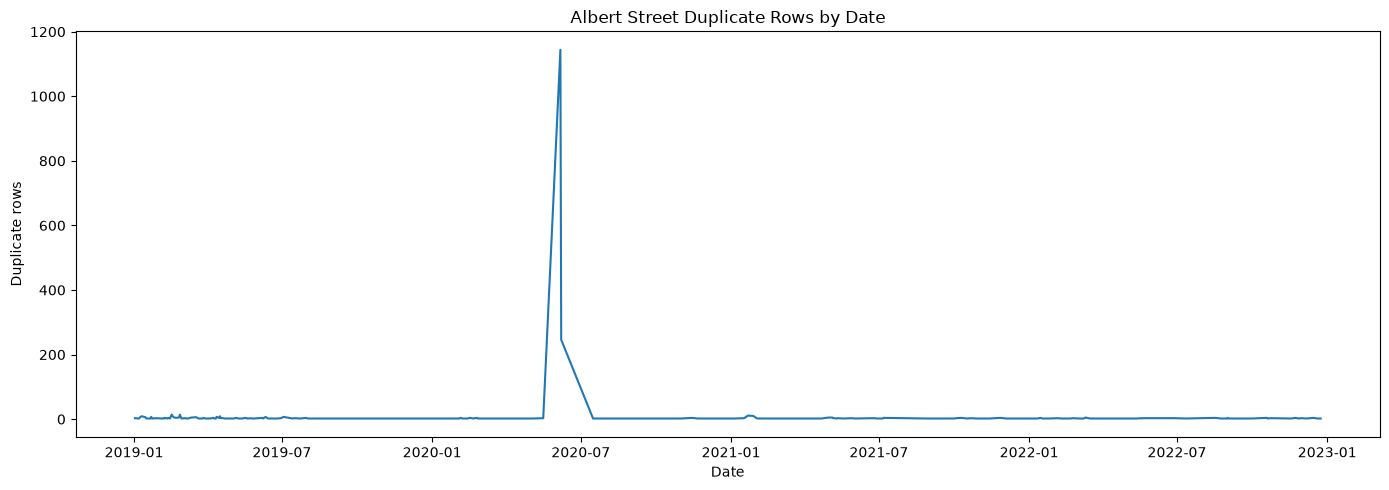

Saved: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\duplicate_investigation\albert_duplicate_rows_by_date.png


In [11]:
plt.figure(figsize=(14, 5))

plt.plot(
    duplicates_by_date.sort_values("DATE_PARSED")["DATE_PARSED"],
    duplicates_by_date.sort_values("DATE_PARSED")["DUPLICATE_ROWS"]
)

plt.title("Albert Street Duplicate Rows by Date")
plt.xlabel("Date")
plt.ylabel("Duplicate rows")
plt.tight_layout()

chart_path = OUTPUT_DIR / "albert_duplicate_rows_by_date.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)


## 10. Compare raw and deduplicated daily counts

This test removes rows that are identical across **all columns**. The original data remain unchanged.


In [12]:
albert_raw["DATE_PARSED"] = pd.to_datetime(
    albert_raw["DATE_PARSED"],
    errors="coerce"
)

albert_clean = albert_raw.drop_duplicates().copy()

print("Original Albert rows:", len(albert_raw))
print("Rows after exact deduplication:", len(albert_clean))
print("Rows removed:", len(albert_raw) - len(albert_clean))


Original Albert rows: 902230
Rows after exact deduplication: 901867
Rows removed: 363


In [13]:
daily_original = (
    albert_raw
    .groupby("DATE_PARSED")
    .size()
    .rename("ORIGINAL_DAILY_COUNT")
    .reset_index()
)

daily_clean = (
    albert_clean
    .groupby("DATE_PARSED")
    .size()
    .rename("DEDUPLICATED_DAILY_COUNT")
    .reset_index()
)

daily_impact = daily_original.merge(
    daily_clean,
    on="DATE_PARSED",
    how="outer"
).fillna(0)

daily_impact["COUNT_DIFFERENCE"] = (
    daily_impact["ORIGINAL_DAILY_COUNT"]
    - daily_impact["DEDUPLICATED_DAILY_COUNT"]
)

print("Days affected by deduplication:",
      int((daily_impact["COUNT_DIFFERENCE"] > 0).sum()))
print("Maximum reduction on one day:",
      int(daily_impact["COUNT_DIFFERENCE"].max()))

daily_impact.sort_values(
    "COUNT_DIFFERENCE",
    ascending=False
).head(20)


Days affected by deduplication: 202
Maximum reduction on one day: 13


,DATE_PARSED,ORIGINAL_DAILY_COUNT,DEDUPLICATED_DAILY_COUNT,COUNT_DIFFERENCE
46,2019-02-16,535,522,13
56,2019-02-26,1971,1961,10
584,2021-01-22,652,642,10
583,2021-01-21,495,486,9
590,2021-01-28,710,701,9
183,2019-07-03,1298,1292,6
9,2019-01-10,1574,1569,5
105,2019-04-16,1788,1783,5
161,2019-06-11,1538,1533,5
49,2019-02-19,1833,1829,4


## 11. Compare before-and-after results with and without deduplication


In [14]:
def before_after_summary(daily_frame, count_column, label):
    data = daily_frame.copy()

    data = data.loc[
        data["DATE_PARSED"] != INTERVENTION_DATE
    ].copy()

    data["PERIOD"] = "Before"
    data.loc[
        data["DATE_PARSED"] > INTERVENTION_DATE,
        "PERIOD"
    ] = "After"

    result = (
        data
        .groupby("PERIOD")[count_column]
        .agg(["count", "mean", "median", "sum"])
        .rename(columns={
            "count": "OBSERVED_DAYS",
            "mean": "AVERAGE_DAILY_COUNT",
            "median": "MEDIAN_DAILY_COUNT",
            "sum": "TOTAL_BICYCLE_DETECTIONS"
        })
        .reset_index()
    )

    before_mean = result.loc[
        result["PERIOD"] == "Before",
        "AVERAGE_DAILY_COUNT"
    ].iloc[0]

    after_mean = result.loc[
        result["PERIOD"] == "After",
        "AVERAGE_DAILY_COUNT"
    ].iloc[0]

    percentage_change = (
        (after_mean - before_mean) / before_mean
    ) * 100

    result["METHOD"] = label
    result["PERCENTAGE_CHANGE"] = percentage_change

    return result

original_comparison = before_after_summary(
    daily_impact[
        ["DATE_PARSED", "ORIGINAL_DAILY_COUNT"]
    ],
    "ORIGINAL_DAILY_COUNT",
    "Original"
)

clean_comparison = before_after_summary(
    daily_impact[
        ["DATE_PARSED", "DEDUPLICATED_DAILY_COUNT"]
    ],
    "DEDUPLICATED_DAILY_COUNT",
    "Exact duplicates removed"
)

comparison = pd.concat(
    [original_comparison, clean_comparison],
    ignore_index=True
)

comparison


,PERIOD,OBSERVED_DAYS,AVERAGE_DAILY_COUNT,MEDIAN_DAILY_COUNT,TOTAL_BICYCLE_DETECTIONS,METHOD,PERCENTAGE_CHANGE
0,After,934,611.138116,544.0,570803,Original,-34.97725
1,Before,352,939.883523,933.0,330839,Original,-34.97725
2,After,934,610.959315,544.0,570636,Exact duplicates removed,-34.95774
3,Before,352,939.326705,932.5,330643,Exact duplicates removed,-34.95774


## 12. Export duplicate-analysis outputs


In [15]:
source_summary.to_csv(
    OUTPUT_DIR / "albert_duplicate_source_summary.csv",
    index=False
)

source_row_summary.to_csv(
    OUTPUT_DIR / "albert_duplicate_source_row_summary.csv",
    index=False
)

duplicate_events.to_csv(
    OUTPUT_DIR / "albert_duplicate_event_groups.csv",
    index=False
)

duplicates_by_source.to_csv(
    OUTPUT_DIR / "albert_duplicates_by_source_file.csv",
    index=False
)

duplicates_by_date.to_csv(
    OUTPUT_DIR / "albert_duplicates_by_date.csv",
    index=False
)

daily_impact.to_csv(
    OUTPUT_DIR / "albert_daily_counts_original_vs_deduplicated.csv",
    index=False
)

comparison.to_csv(
    OUTPUT_DIR / "albert_before_after_duplicate_sensitivity.csv",
    index=False
)

albert_clean.to_csv(
    OUTPUT_DIR / "albert_raw_exact_duplicates_removed.csv",
    index=False
)

print("All outputs saved to:", OUTPUT_DIR)


All outputs saved to: C:\Users\f_tir\Documents\Code\Victoria-Urban-Planning\data\processed\cycling_counters\duplicate_investigation


## 13. Interpretation guide

We can use the outputs results to answer to following questions:

- Are most duplicates repeated inside the same CSV?
- Do identical observations appear across different CSV or ZIP files?
- Does each duplicate group usually occur twice, or more than twice?
- What proportion of Albert's raw records is affected?
- How many daily totals change after exact duplicates are removed?
- Does the before/after percentage change differ materially after deduplication?


## 13. Conclusion

The duplicate investigation identified repeated Albert Street records originating from several source patterns:

- **572 duplicate groups** occurred across different ZIP files.
- **243 duplicate groups** occurred within the same CSV file.
- **123 duplicate groups** occurred across different CSV files within the same ZIP.
- Some observations occurred more than twice, with the largest identified duplicate group appearing **14 times**.

The largest category was therefore duplicates occurring **across different ZIP files**. This indicates that duplicate records are not limited to a single CSV file and may be associated with overlapping or repeated source files in the supplied data.

This notebook identifies where the duplicate records originate. The effect of removing exact duplicates on the before-and-after analysis is assessed separately in **`03_duplicate_sensitivity.ipynb`**.